In [4]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
    "numpy==1.26.4", "-q"])

subprocess.check_call([sys.executable, "-m", "pip", "install",
    "nltk", "wordcloud", "gensim", "gradio",
    "scikit-learn", "tensorflow", "seaborn", "-q"])

print("All packages installed.")

All packages installed.


# Part III - Language Tasks
## Text Classification using RNN on News Headlines

Dataset: news_category.csv (headline, category)  
Task: predict the category of a news headline using 3 different RNN models

## Imports and Setup

In [6]:
import os
import re
import json
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from gensim.models import Word2Vec

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')

I0000 00:00:1778373327.887602   50519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778373328.325501   50519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778373330.361769   50519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All libraries imported successfully.


In [7]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('NLTK resources ready.')

NLTK resources ready.


In [9]:
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Memory growth enabled')
    except RuntimeError as e:
        print(e)

print('GPU Available:', len(gpu_devices) > 0)
print('GPU Devices :', gpu_devices)

Memory growth enabled
GPU Available: True
GPU Devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import os

_nb_dir = os.path.join(os.getcwd(), 'assessment-2')
if os.path.isdir(_nb_dir):
    os.chdir(_nb_dir)
elif os.path.basename(os.getcwd()) != 'assessment-2':
    # try current dir and parent in case we launched jupyter from the wrong folder
    for _p in [os.getcwd(),
               os.path.join(os.getcwd(), '..', 'assessment-2')]:
        if os.path.exists(os.path.join(_p, 'data', 'news_category.csv')):
            os.chdir(_p)
            break

print('Working directory:', os.getcwd())
assert os.path.exists('./Data/6. News Category Dataset'), \
    f'Still cannot find data file in {os.getcwd()}'

Working directory: /home/bharat/assessment


# Part 1 - Text Preprocessing, Tokenization and Padding

## Loading the Dataset

In [15]:
news_df = pd.read_csv('./Data/6. News Category Dataset/news_category.csv')
print(f'Shape   : {news_df.shape}')
print(f'Columns : {news_df.columns.tolist()}')
news_df.head(10)

Shape   : (11025, 2)
Columns : ['headline', 'category']


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


### Data Overview

In [16]:
print('Data Types:')
print(news_df.dtypes)
print('\nNull Values:')
print(news_df.isnull().sum())
print(f'\nTotal Samples: {len(news_df):,}')

Data Types:
headline    str
category    str
dtype: object

Null Values:
headline    0
category    0
dtype: int64

Total Samples: 11,025


Category Distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


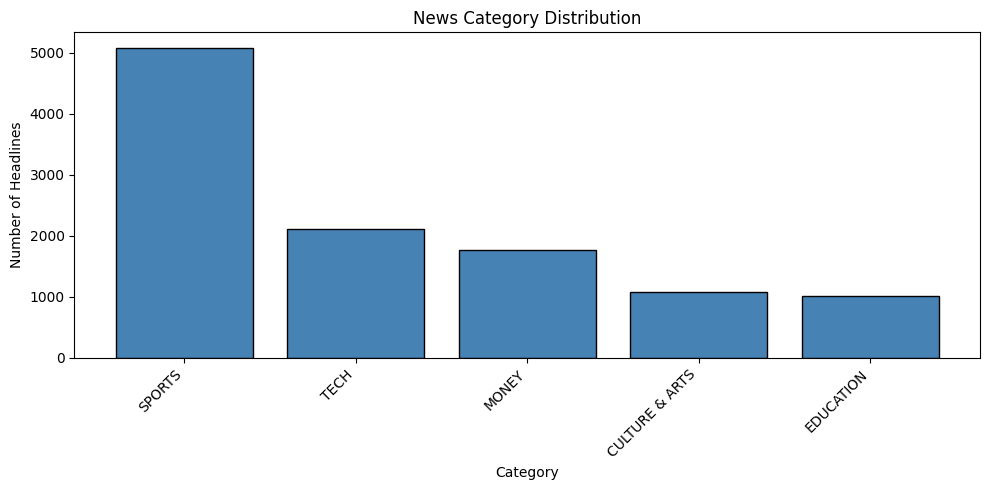

In [17]:
print('Category Distribution:')
print(news_df['category'].value_counts())

cat_counts = news_df['category'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('News Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.show()

## Text Cleaning

steps applied to each headline before tokenizing:
1. lowercase everything
2. expand contractions (e.g. don't -> do not)
3. strip URLs, @mentions, #hashtags, and numbers
4. remove stopwords
5. lemmatize each word to its base form

In [18]:
CONTRACTIONS = {
    "don't": 'do not',    "doesn't": 'does not',  "didn't": 'did not',
    "won't": 'will not',  "can't": 'cannot',       "couldn't": 'could not',
    "shouldn't": 'should not', "wouldn't": 'would not', "isn't": 'is not',
    "aren't": 'are not',  "wasn't": 'was not',     "weren't": 'were not',
    "i'm": 'i am',        "i've": 'i have',        "i'll": 'i will',
    "i'd": 'i would',     "you're": 'you are',     "you've": 'you have',
    "you'll": 'you will', "he's": 'he is',         "she's": 'she is',
    "it's": 'it is',      "we're": 'we are',       "they're": 'they are',
    "they've": 'they have', "they'll": 'they will', "that's": 'that is',
    "there's": 'there is', "here's": 'here is',    "let's": 'let us',
    "what's": 'what is',  "who's": 'who is',       "n't": ' not'
}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text


def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)


news_df['cleaned_headline'] = news_df['headline'].apply(clean_text)
print('Sample cleaned headlines:')
for i in range(5):
    print(f'\nOriginal : {news_df["headline"].iloc[i]}')
    print(f'Cleaned  : {news_df["cleaned_headline"].iloc[i]}')

Sample cleaned headlines:

Original : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned  : new documentary capture complexity child immigrant

Original : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Cleaned  : twitch ban gambling site streamer scam folk

Original : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Cleaned  : reboot clever navelgazey look inside tv reboots

Original : Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
Cleaned  : maury will basestealing shortstop dodger dy

Original : Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
Cleaned  : la vega ace win first wnba title chelsea gray named mvp


## Visualizing Cleaned Data

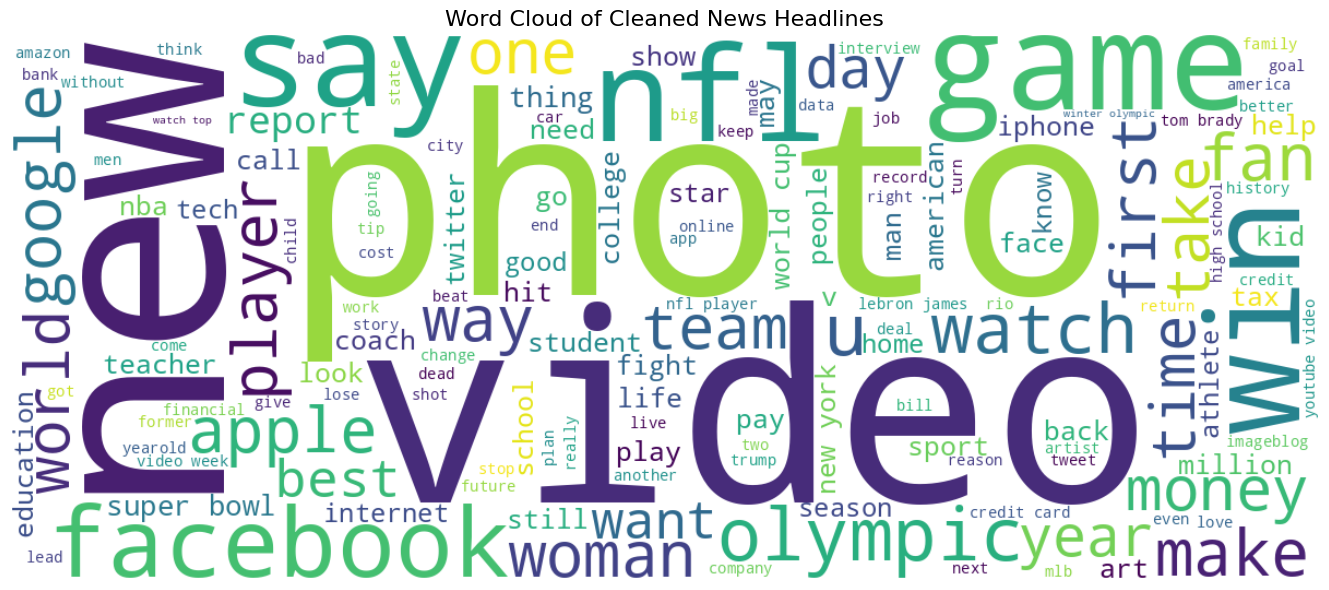

In [19]:
corpus_text = ' '.join(news_df['cleaned_headline'].values)

wcloud = WordCloud(
    width=1200, height=500, background_color='white',
    max_words=150, colormap='viridis'
).generate(corpus_text)

plt.figure(figsize=(15, 6))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned News Headlines', fontsize=16)
plt.tight_layout()
plt.show()

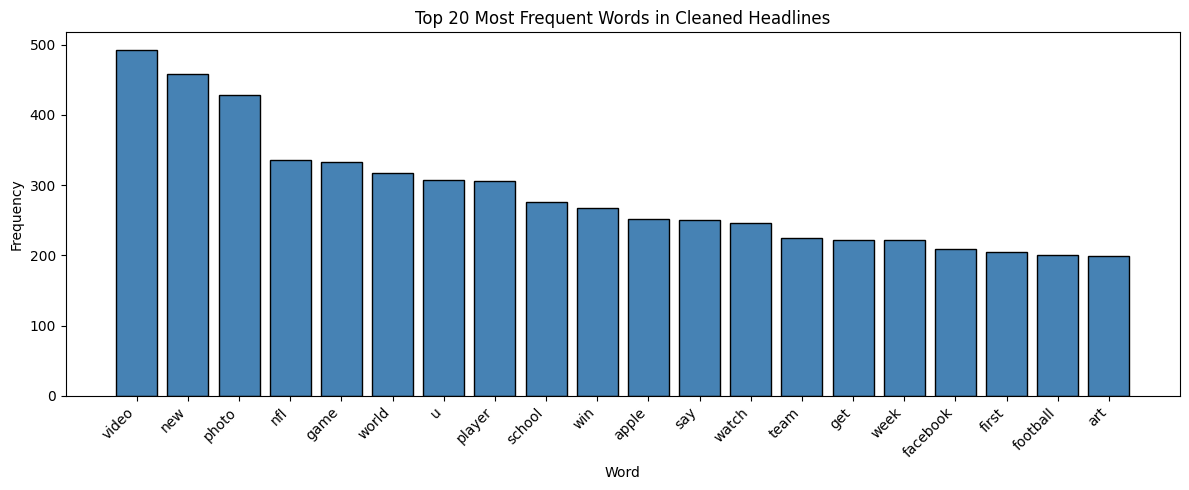

In [20]:
corpus_words = corpus_text.split()
word_counts = Counter(corpus_words)
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words in Cleaned Headlines')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

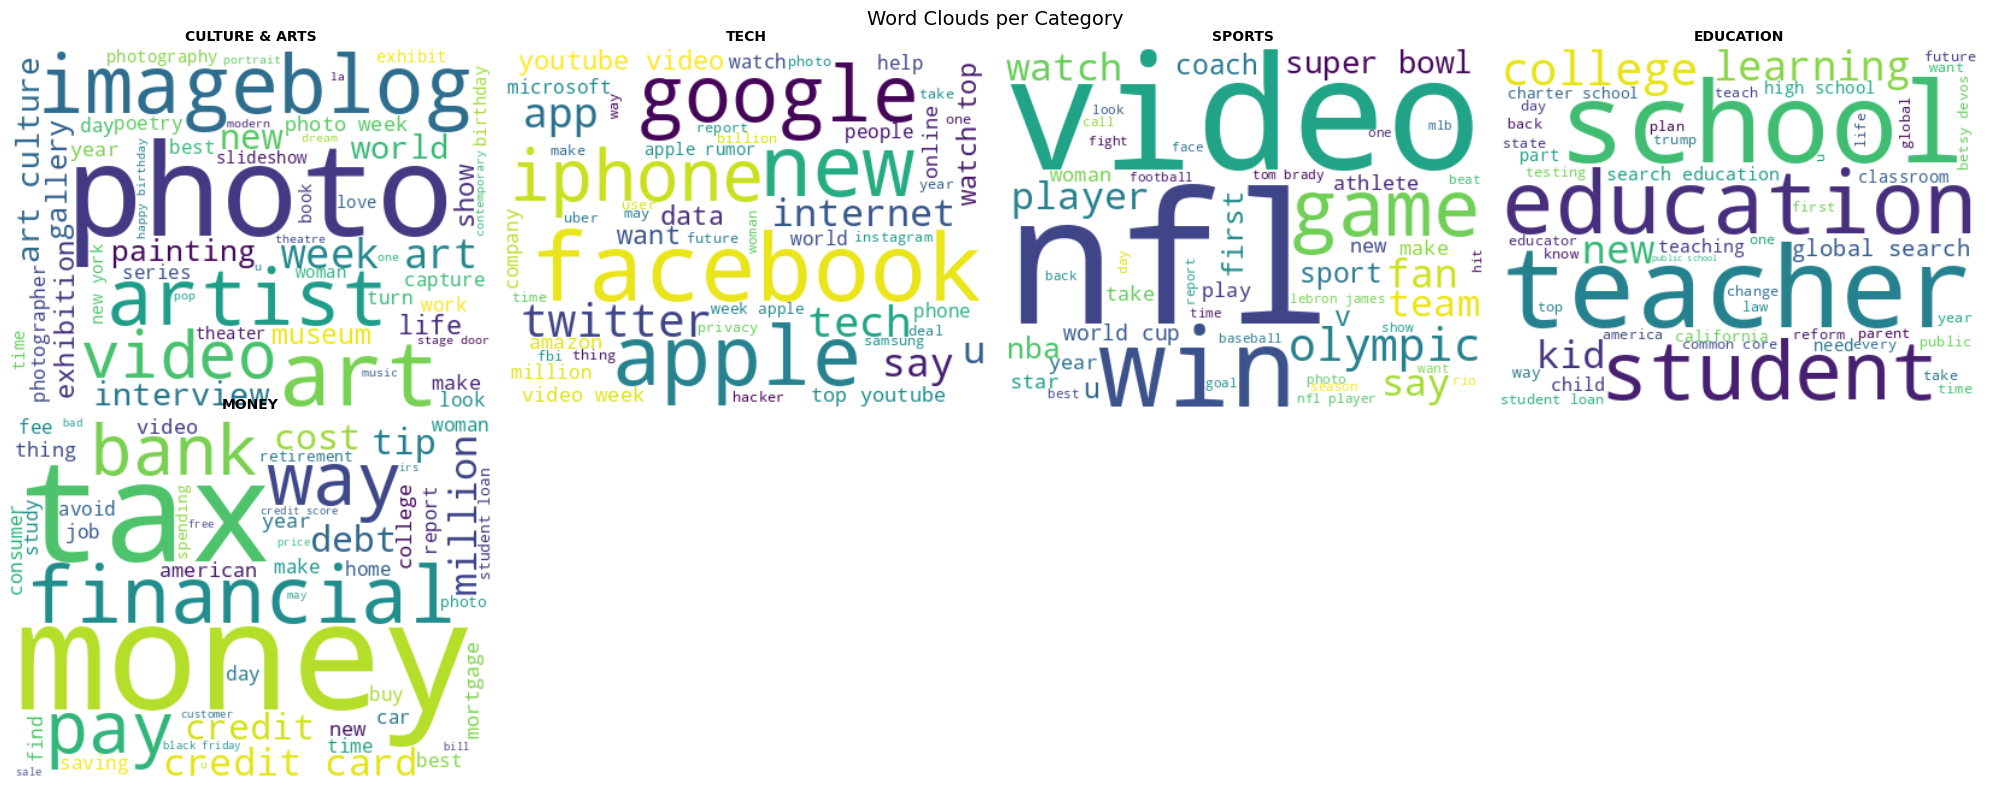

In [21]:
categories = news_df['category'].unique()
num_cats = len(categories)
cols = min(num_cats, 4)
rows = (num_cats + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).flatten()

for ax, cat in zip(axes, categories):
    cat_text = ' '.join(news_df[news_df['category'] == cat]['cleaned_headline'].values)
    wc = WordCloud(width=400, height=300, background_color='white', max_words=50).generate(cat_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.axis('off')

for ax in axes[num_cats:]:
    ax.axis('off')

plt.suptitle('Word Clouds per Category', fontsize=14)
plt.tight_layout()
plt.show()

## Label Encoding

In [22]:
label_enc = LabelEncoder()
news_df['label'] = label_enc.fit_transform(news_df['category'])

n_classes = len(label_enc.classes_)
category_names = label_enc.classes_

print(f'Number of classes: {n_classes}')
print('\nClass mapping:')
for i, cls in enumerate(category_names):
    print(f'  {i}: {cls}')

Number of classes: 5

Class mapping:
  0: CULTURE & ARTS
  1: EDUCATION
  2: MONEY
  3: SPORTS
  4: TECH


## Tokenization and Padding

In [23]:
features = news_df['cleaned_headline'].values
targets = news_df['label'].values

train_texts, test_texts, train_labels, test_labels = train_test_split(
    features, targets, test_size=0.2, random_state=42, stratify=targets
)

print(f'Training samples : {len(train_texts):,}')
print(f'Testing samples  : {len(test_texts):,}')

Training samples : 8,820
Testing samples  : 2,205


In [25]:
VOCAB_SIZE = 10000

text_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
text_tokenizer.fit_on_texts(train_texts)

train_seqs = text_tokenizer.texts_to_sequences(train_texts)
test_seqs  = text_tokenizer.texts_to_sequences(test_texts)

print(f'Vocabulary size   : {len(text_tokenizer.word_index):,}')
print(f'\nSample headline  : {train_texts[0]}')
print(f'Encoded sequence  : {train_seqs[0]}')

Vocabulary size   : 12,036

Sample headline  : need know apple fbi showdown dc
Encoded sequence  : [63, 66, 12, 366, 2124, 775]


Sequence Length Stats:
  Min    : 1
  Mean   : 6.9
  Median : 7.0
  95th % : 11  <- used as MAX_LEN
  Max    : 18


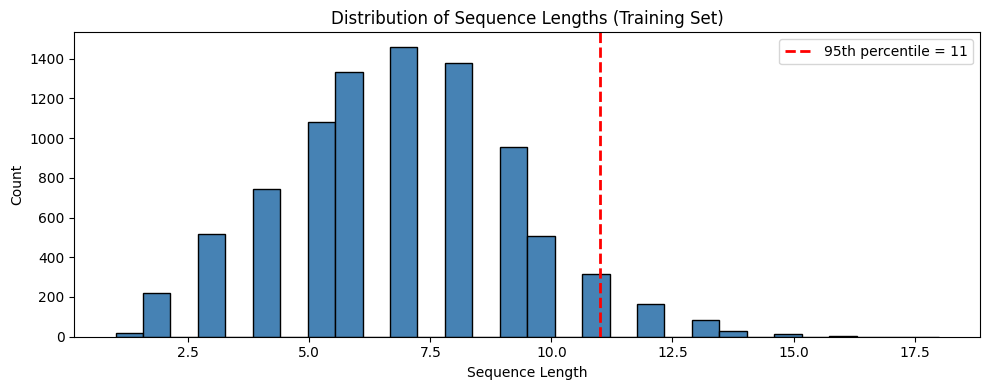

In [26]:
sequence_lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(sequence_lengths, 95))

print('Sequence Length Stats:')
print(f'  Min    : {min(sequence_lengths)}')
print(f'  Mean   : {np.mean(sequence_lengths):.1f}')
print(f'  Median : {np.median(sequence_lengths):.1f}')
print(f'  95th % : {MAX_LEN}  <- used as MAX_LEN')
print(f'  Max    : {max(sequence_lengths)}')

plt.figure(figsize=(10, 4))
plt.hist(sequence_lengths, bins=30, edgecolor='black', color='steelblue')
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Sequence Lengths (Training Set)')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
train_padded = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
test_padded  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Padded train shape : {train_padded.shape}')
print(f'Padded test shape  : {test_padded.shape}')
print(f'\nSample padded sequence: {train_padded[0]}')

Padded train shape : (8820, 11)
Padded test shape  : (2205, 11)

Sample padded sequence: [  63   66   12  366 2124  775    0    0    0    0    0]


# Part 2 - Model Building

3 models to compare:
1. Model 1 - SimpleRNN with trainable Embedding
2. Model 2 - LSTM with trainable Embedding
3. Model 3 - LSTM using pretrained Word2Vec embeddings (frozen weights)

In [29]:
EMBED_DIM = 128   # increased from 64 for richer word representations

## Model 1 - SimpleRNN

In [30]:
simple_rnn_net = Sequential(name='SimpleRNN_Model')
simple_rnn_net.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
simple_rnn_net.add(SimpleRNN(128, return_sequences=True, recurrent_dropout=0.2))
simple_rnn_net.add(Dropout(0.3))
simple_rnn_net.add(SimpleRNN(64, return_sequences=False))
simple_rnn_net.add(Dropout(0.3))
simple_rnn_net.add(Dense(128, activation='relu'))
simple_rnn_net.add(BatchNormalization())
simple_rnn_net.add(Dropout(0.3))
simple_rnn_net.add(Dense(n_classes, activation='softmax'))

simple_rnn_net.summary()

I0000 00:00:1778373992.533878   50519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model 2 - LSTM

In [31]:
lstm_net = Sequential(name='LSTM_Model')
lstm_net.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
lstm_net.add(Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)))
lstm_net.add(Dropout(0.3))
lstm_net.add(Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.2)))
lstm_net.add(Dropout(0.3))
lstm_net.add(Dense(128, activation='relu'))
lstm_net.add(BatchNormalization())
lstm_net.add(Dropout(0.3))
lstm_net.add(Dense(n_classes, activation='softmax'))

lstm_net.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model 3 - LSTM + Word2Vec (frozen)

In [32]:
tokenized_docs = [text.split() for text in train_texts]

word2vec_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=EMBED_DIM,   # must match EMBED_DIM
    window=7,                # wider context window
    min_count=1,
    workers=4,
    epochs=30,               # more training passes
    sg=1                     # skip-gram: better for rare words
)

print(f'Word2Vec vocabulary size: {len(word2vec_model.wv):,}')
print(f'Embedding dimension     : {word2vec_model.wv.vector_size}')

Word2Vec vocabulary size: 12,035
Embedding dimension     : 128


In [34]:
vocab_index = text_tokenizer.word_index
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

matched, unmatched = 0, 0
for word, idx in vocab_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in word2vec_model.wv:
        embed_matrix[idx] = word2vec_model.wv[word]
        matched += 1
    else:
        unmatched += 1

print(f'Embedding matrix shape : {embed_matrix.shape}')
print(f'Words covered          : {matched:,} ({matched / (matched + unmatched + 1e-9):.1%})')
print(f'Words missing          : {unmatched:,}')

Embedding matrix shape : (10000, 128)
Words covered          : 9,998 (100.0%)
Words missing          : 1


In [35]:
lstm_w2v_net = Sequential(name='LSTM_Word2Vec_Model')
lstm_w2v_net.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        weights=[embed_matrix],
        trainable=False
    )
)
lstm_w2v_net.add(Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)))
lstm_w2v_net.add(Dropout(0.3))
lstm_w2v_net.add(Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.2)))
lstm_w2v_net.add(Dropout(0.3))
lstm_w2v_net.add(Dense(128, activation='relu'))
lstm_w2v_net.add(BatchNormalization())
lstm_w2v_net.add(Dropout(0.3))
lstm_w2v_net.add(Dense(n_classes, activation='softmax'))

lstm_w2v_net.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,280,000 (4.88 MB)

# Part 3 - Training and Evaluation

In [38]:
os.makedirs('models', exist_ok=True)
os.makedirs('history', exist_ok=True)

# compute class weights to handle any class imbalance
cls_weights_arr = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
cls_weight_map = dict(enumerate(cls_weights_arr))
print('Class weights:', {label_enc.classes_[k]: f'{v:.3f}' for k, v in cls_weight_map.items()})

training_logs = {}

model_registry = {
    'Simple RNN':      simple_rnn_net,
    'LSTM':            lstm_net,
    'LSTM + Word2Vec': lstm_w2v_net,
}

for name, model in model_registry.items():
    model_key = name.lower().replace(' ', '_').replace('+', 'plus').replace('2', 'two')

    early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    checkpoint = ModelCheckpoint(
        f'models/{model_key}_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    print(f"\n{'='*50}\n  Training: {name}\n{'='*50}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()
    history = model.fit(
        train_padded, train_labels,
        validation_split=0.1,
        epochs=30,
        batch_size=64,
        class_weight=cls_weight_map,
        callbacks=[early_stop, checkpoint, reduce_lr],
        verbose=1
    )
    elapsed_time = time.time() - start_time
    print(f'Time: {elapsed_time:.0f}s  |  Epochs run: {len(history.history["loss"])}/30')

    training_logs[name] = history.history
    model.save(f'models/{model_key}.keras')
    with open(f'history/{model_key}_history.json', 'w') as f:
        json.dump(history.history, f)

print('\nAll models trained and saved.')

Class weights: {'CULTURE & ARTS': '2.054', 'EDUCATION': '2.175', 'MONEY': '1.256', 'SPORTS': '0.434', 'TECH': '1.048'}

  Training: Simple RNN
Epoch 1/30


I0000 00:00:1778374271.951814   58255 service.cc:153] XLA service 0x7457b00357c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778374271.951859   58255 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778374272.071681   58255 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778374272.657441   58255 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778374272.808295   58255 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_Model_1_simple_rnn_1_2_while_body_3264_grad_3608_const_0__.35.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778374272.809161   58255 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_Model_1_simple_rnn_1_while_body_3123_grad_3845_const_0__.42.clone.clone.clone.clone.clone.clone.clone
I

  9/125 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1961 - loss: 2.4720

I0000 00:00:1778374283.986513   58255 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2135 - loss: 2.1832

I0000 00:00:1778374285.638921   58252 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_Model_1_simple_rnn_1_2_while_body_3264_grad_3608_const_0__.35.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778374285.639028   58252 dot_merger.cc:481] Merging Dots in computation: SimpleRNN_Model_1_simple_rnn_1_while_body_3123_grad_3845_const_0__.42.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778374285.639081   58252 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4600__.45


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2150 - loss: 2.1752

I0000 00:00:1778374290.549785   58255 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778374291.805810   58252 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778374292.276112   61105 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1778374292.332522   58252 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Workin

125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.2528 - loss: 1.9794 - val_accuracy: 0.4354 - val_loss: 1.3366 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4324 - loss: 1.4836 - val_accuracy: 0.6247 - val_loss: 1.0223 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6456 - loss: 1.0150 - val_accuracy: 0.7177 - val_loss: 0.8557 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8098 - loss: 0.5988 - val_accuracy: 0.7959 - val_loss: 0.7413 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8794 - loss: 0.3985 - val_accuracy: 0.7551 - val_loss: 0.9416 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9305 - loss: 0.2365 - val_accuracy: 0.7857 - val_loss: 0.9543 - learning_rate: 0.0010
Epoch 7/30
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9518 - loss: 0.1643
Epoch 7: R

## Loss and Accuracy Curves

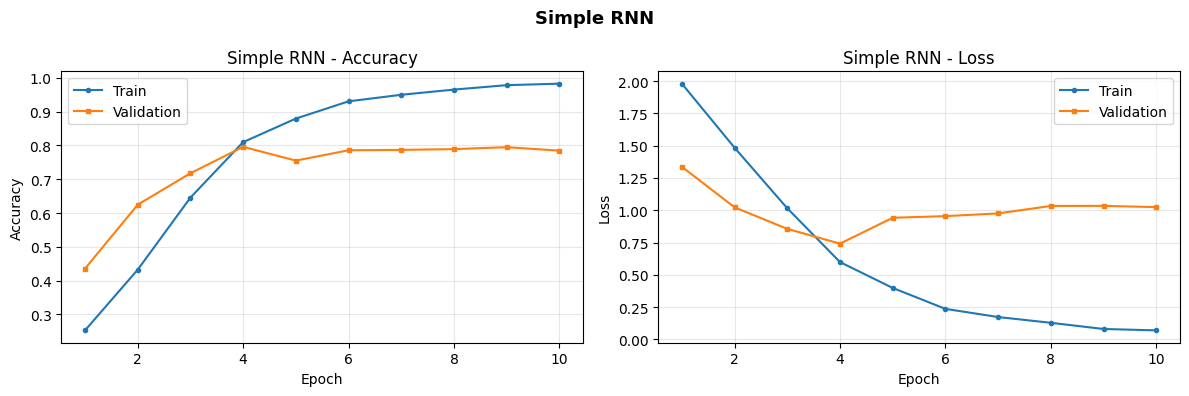

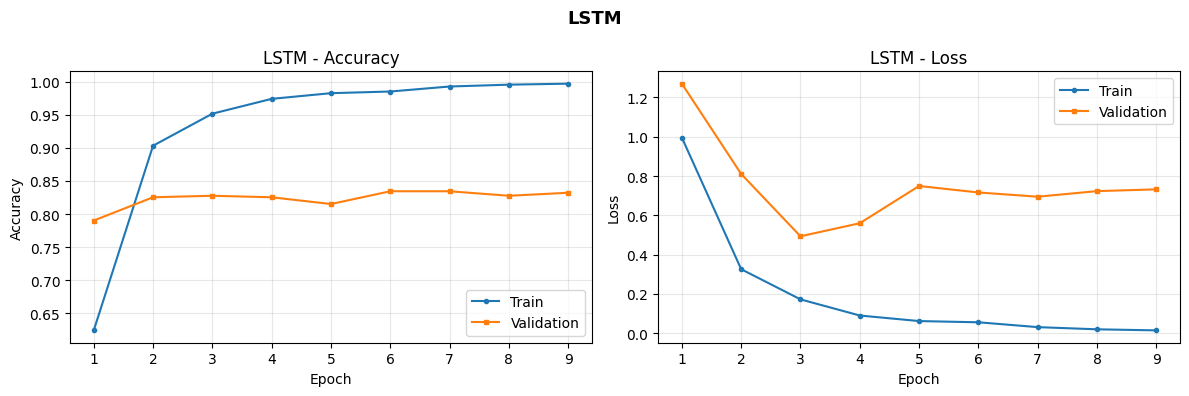

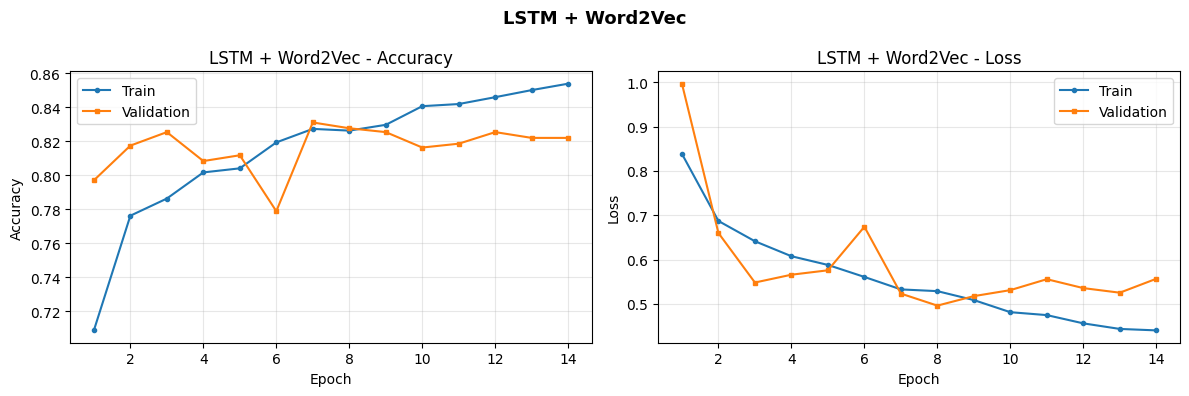

In [39]:
for name, hist in training_logs.items():
    epochs = range(1, len(hist['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, hist['accuracy'],     label='Train',      marker='o', markersize=3)
    ax1.plot(epochs, hist['val_accuracy'], label='Validation', marker='s', markersize=3)
    ax1.set_title(f'{name} - Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, hist['loss'],     label='Train',      marker='o', markersize=3)
    ax2.plot(epochs, hist['val_loss'], label='Validation', marker='s', markersize=3)
    ax2.set_title(f'{name} - Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Model Comparison

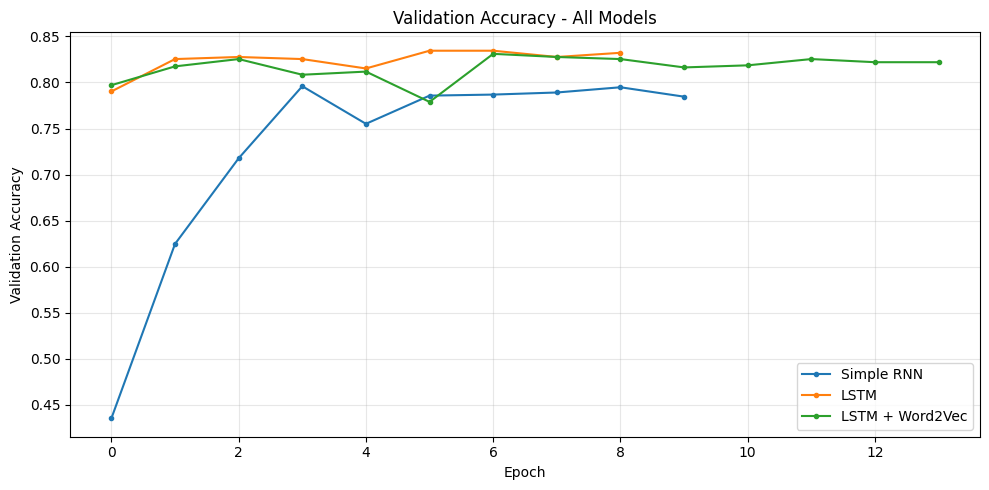

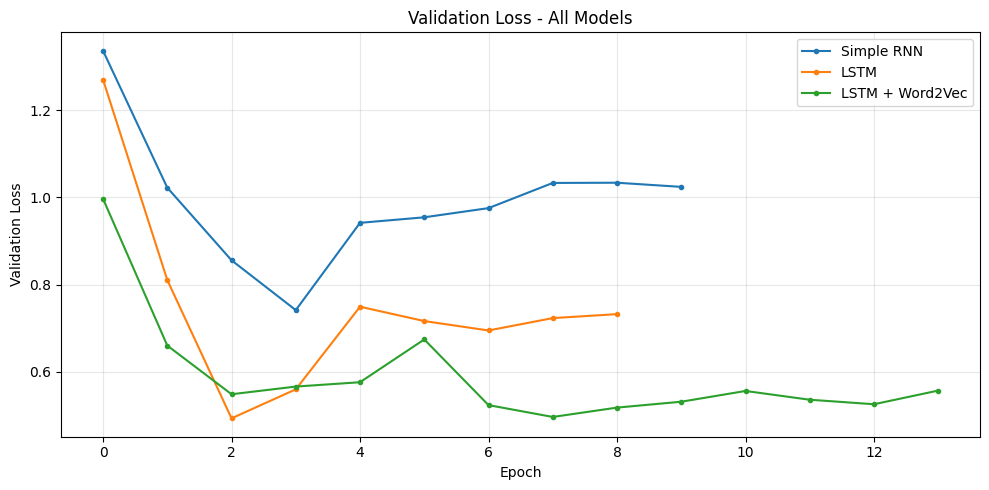


Model                 Best Val Acc  Best Val Loss   Epochs
---------------------------------------------------------
Simple RNN                 79.59%         0.7413       10
LSTM                       83.45%         0.4930        9
LSTM + Word2Vec            83.11%         0.4962       14


In [40]:
plt.figure(figsize=(10, 5))
for name, hist in training_logs.items():
    plt.plot(hist['val_accuracy'], label=name, marker='o', markersize=3)
plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, hist in training_logs.items():
    plt.plot(hist['val_loss'], label=name, marker='o', markersize=3)
plt.title('Validation Loss - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<20} {'Best Val Acc':>13} {'Best Val Loss':>14} {'Epochs':>8}")
print('-' * 57)
for name, hist in training_logs.items():
    print(
        f"{name:<20}"
        f" {max(hist['val_accuracy']):>12.2%}"
        f" {min(hist['val_loss']):>14.4f}"
        f" {len(hist['loss']):>8}"
    )

## Test Set Evaluation

I0000 00:00:1778375329.412010   58256 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778375329.889883   71645 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_25', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1778375331.466176   58252 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778375331.838821   71709 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_21', 12 bytes spill stores, 12 bytes spill loads




  Simple RNN
  Test Accuracy: 0.7610 (76.10%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.62      0.63      0.62       215
     EDUCATION       0.65      0.58      0.61       203
         MONEY       0.75      0.68      0.71       351
        SPORTS       0.84      0.90      0.87      1015
          TECH       0.68      0.66      0.67       421

      accuracy                           0.76      2205
     macro avg       0.71      0.69      0.70      2205
  weighted avg       0.76      0.76      0.76      2205



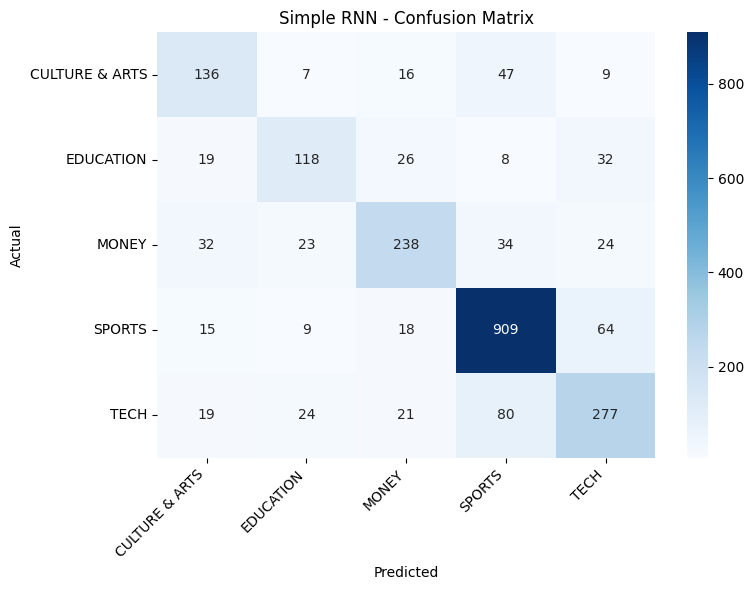


  LSTM
  Test Accuracy: 0.8136 (81.36%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.52      0.80      0.63       215
     EDUCATION       0.87      0.55      0.67       203
         MONEY       0.77      0.74      0.76       351
        SPORTS       0.90      0.92      0.91      1015
          TECH       0.84      0.76      0.80       421

      accuracy                           0.81      2205
     macro avg       0.78      0.75      0.75      2205
  weighted avg       0.83      0.81      0.82      2205



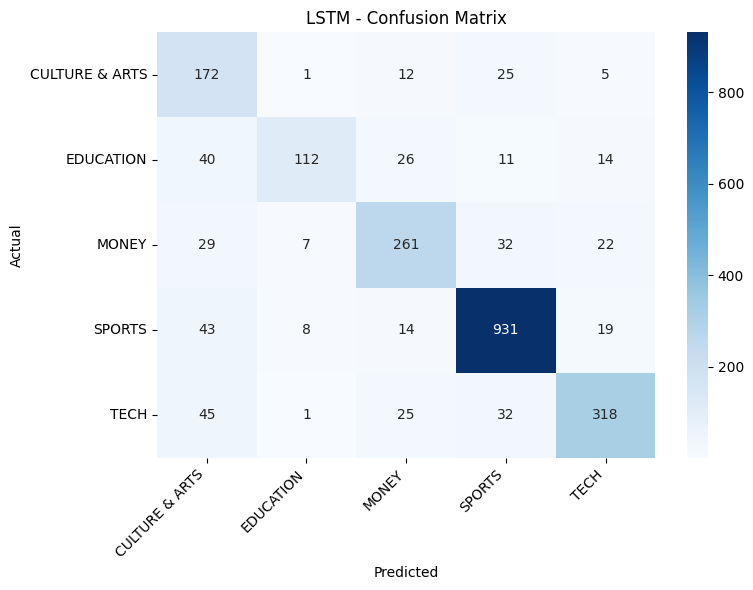


  LSTM + Word2Vec
  Test Accuracy: 0.8322 (83.22%)

                precision    recall  f1-score   support

CULTURE & ARTS       0.64      0.82      0.72       215
     EDUCATION       0.61      0.76      0.67       203
         MONEY       0.83      0.75      0.79       351
        SPORTS       0.94      0.91      0.92      1015
          TECH       0.84      0.77      0.80       421

      accuracy                           0.83      2205
     macro avg       0.77      0.80      0.78      2205
  weighted avg       0.84      0.83      0.84      2205



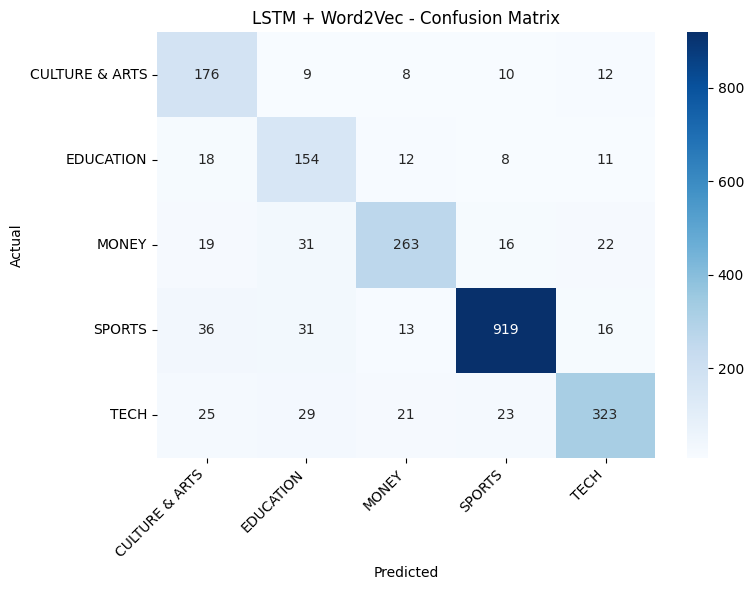

In [41]:
evaluation_models = {
    'Simple RNN':      simple_rnn_net,
    'LSTM':            lstm_net,
    'LSTM + Word2Vec': lstm_w2v_net,
}

for name, model in evaluation_models.items():
    y_pred = np.argmax(model.predict(test_padded, verbose=0), axis=1)
    acc    = accuracy_score(test_labels, y_pred)

    print(f"\n{'='*60}")
    print(f'  {name}')
    print(f"{'='*60}")
    print(f'  Test Accuracy: {acc:.4f} ({acc:.2%})')
    print()
    print(classification_report(test_labels, y_pred, target_names=category_names))

    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=category_names, yticklabels=category_names
    )
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Part 4 - Error Analysis

## Misclassified Examples

In [42]:
top_model      = lstm_w2v_net
top_model_name = 'LSTM + Word2Vec'

top_model_preds = np.argmax(top_model.predict(test_padded, verbose=0), axis=1)
wrong_indices = np.where(top_model_preds != test_labels)[0]

print(f'Model           : {top_model_name}')
print(f'Total samples   : {len(test_labels):,}')
print(f'Misclassified   : {len(wrong_indices):,}')
print(f'Accuracy        : {1 - len(wrong_indices)/len(test_labels):.2%}')
print()
print('Sample Misclassified Headlines:')
print('=' * 70)

for rank, i in enumerate(wrong_indices[:3], 1):
    print(f'\nExample {rank}:')
    print(f'  Original  : {test_texts[i]}')
    print(f'  True label: {category_names[test_labels[i]]}')
    print(f'  Predicted : {category_names[top_model_preds[i]]}')
    print('-' * 70)

Model           : LSTM + Word2Vec
Total samples   : 2,205
Misclassified   : 370
Accuracy        : 83.22%

Sample Misclassified Headlines:

Example 1:
  Original  : game boy childhood dream finally exists
  True label: TECH
  Predicted : CULTURE & ARTS
----------------------------------------------------------------------

Example 2:
  Original  : judicial negligence compound political negligence south carolina
  True label: EDUCATION
  Predicted : CULTURE & ARTS
----------------------------------------------------------------------

Example 3:
  Original  : tale autism spectrum friend amberdawn
  True label: CULTURE & ARTS
  Predicted : EDUCATION
----------------------------------------------------------------------


## Model Complexity vs Performance

          Model  Parameters  Test Accuracy  Best Val Accuracy  Epochs Trained
     Simple RNN     1334725         0.7610             0.7959              10
           LSTM     1725189         0.8136             0.8345               9
LSTM + Word2Vec     1725189         0.8322             0.8311              14


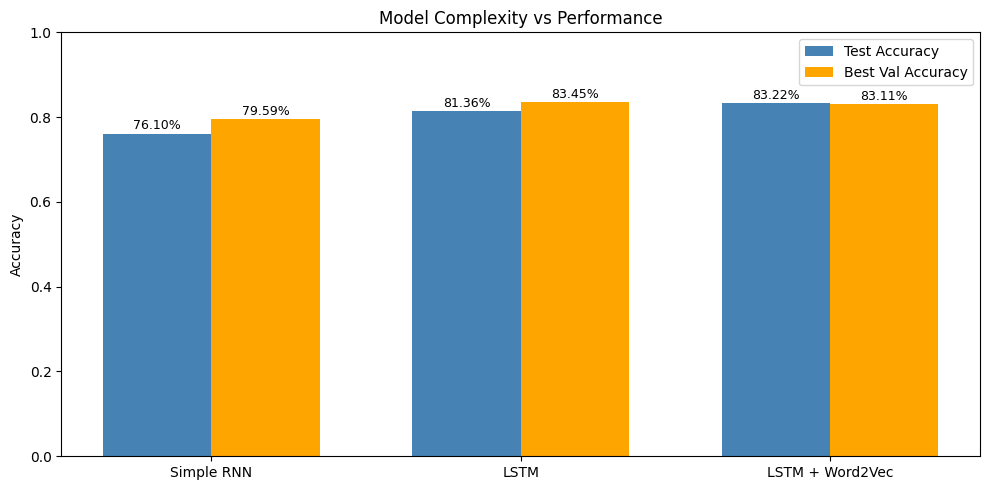

In [43]:
perf_data = []
for name, model in evaluation_models.items():
    total_params = model.count_params()
    y_pred = np.argmax(model.predict(test_padded, verbose=0), axis=1)
    acc = accuracy_score(test_labels, y_pred)
    perf_data.append({
        'Model': name,
        'Parameters': total_params,
        'Test Accuracy': round(acc, 4),
        'Best Val Accuracy': round(max(training_logs[name]['val_accuracy']), 4),
        'Epochs Trained': len(training_logs[name]['loss'])
    })

perf_df = pd.DataFrame(perf_data)
print(perf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(perf_df))
width = 0.35
bars1 = ax.bar(x - width/2, perf_df['Test Accuracy'],     width, label='Test Accuracy',     color='steelblue')
bars2 = ax.bar(x + width/2, perf_df['Best Val Accuracy'], width, label='Best Val Accuracy', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(perf_df['Model'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Complexity vs Performance')
ax.legend()
ax.set_ylim(0, 1)
for bar in list(bars1) + list(bars2):
    ax.annotate(
        f'{bar.get_height():.2%}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9
    )
plt.tight_layout()
plt.show()

## Why the model gets it wrong

**Common error patterns:**

1. **Overlapping words** - words like 'game', 'win', 'show' appear in multiple categories so the model gets confused

2. **Headlines are short** - after removing stopwords, some headlines are only 2-3 tokens which isn't much signal to work with

3. **Ambiguous words** - common words like 'new', 'report', 'star' appear across all categories and don't help narrow it down

**Improvements already applied in this notebook:**

| Change | Why it helped |
|---|---|
| Bidirectional stacked LSTM | reads headline both left-to-right and right-to-left |
| Embedding dim 64 -> 128 | richer word vectors |
| recurrent_dropout on LSTM | reduces overfitting |
| BatchNormalization | smoother training |
| Balanced class weights | stops the model from just predicting the majority class |
| Word2Vec skip-gram, window=7, 30 epochs | better embeddings for short headlines |

**Still worth trying:**

| Idea | Expected gain |
|---|---|
| GloVe 300d or Google News Word2Vec | better pretrained vectors than in-corpus W2V |
| Fine-tune DistilBERT | should push accuracy above 90% |
| Data augmentation (synonym swap) | helps underrepresented classes |
| Skip lemmatizer for proper nouns | currently corrupts names (e.g. Wills -> will) |

# Part 5 - Gradio GUI

simple interface to test the models on any headline you want

In [44]:
import gradio as gr


def predict_headline(headline: str, model_choice: str) -> tuple:
    model_lookup = {
        'Simple RNN':      simple_rnn_net,
        'LSTM':            lstm_net,
        'LSTM + Word2Vec': lstm_w2v_net,
    }
    if not headline.strip():
        return 'Please enter a headline.', {}

    model   = model_lookup[model_choice]
    cleaned = clean_text(headline)
    seq     = text_tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    probs   = model.predict(padded, verbose=0)[0]
    predicted_idx = int(np.argmax(probs))

    prediction_label      = f'**{category_names[predicted_idx]}** ({probs[predicted_idx]:.1%} confidence)'
    confidence_scores = {category_names[i]: float(probs[i]) for i in range(len(category_names))}
    return prediction_label, confidence_scores


demo = gr.Interface(
    fn=predict_headline,
    inputs=[
        gr.Textbox(
            label='News Headline',
            placeholder='e.g. Scientists discover new planet outside our solar system',
            lines=2
        ),
        gr.Dropdown(
            choices=['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
            label='Select Model',
            value='LSTM + Word2Vec'
        )
    ],
    outputs=[
        gr.Markdown(label='Prediction'),
        gr.Label(label='Confidence Scores', num_top_classes=n_classes)
    ],
    title='News Category Classifier',
    description='Enter any news headline to classify it using RNN or LSTM models trained on the news category dataset.',
    examples=[
        ['Scientists discover a new species of dinosaur in Argentina',  'LSTM + Word2Vec'],
        ['Apple unveils new iPhone with AI-powered camera',             'LSTM + Word2Vec'],
        ['Lakers win the NBA championship after overtime thriller',     'LSTM + Word2Vec'],
        ['School introduces AI tutoring tools for students',           'LSTM + Word2Vec'],
    ]
)

demo.launch(share=False, inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
